### Business Problem Statement

Student burnout has become a growing concern in modern education due to increasing academic pressure, changing study habits, and the widespread adoption of Generative AI tools. High levels of burnout can negatively impact academic performance, mental well-being, engagement, and overall student success.

Educational institutions often struggle to identify students who are at risk of burnout before it begins to significantly affect their academic and personal lives. With the availability of data related to AI usage patterns, study behavior, academic performance, anxiety levels, sleep habits, and institutional policies, there is an opportunity to proactively assess burnout risk.

The objective of this project is to develop an Artificial Neural Network (ANN) model that predicts a student's burnout risk level (Low, Medium, or High) based on behavioral, academic, and AI usage factors. By accurately identifying at-risk students, educational institutions can implement targeted interventions, provide support services, and promote healthier learning environments to improve student well-being and academic outcomes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv('ai_student_impact_dataset.csv')

In [4]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df.shape

(50000, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [7]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [8]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [9]:
df.duplicated().sum()

0

In [10]:
df.drop('Student_ID',axis=1,inplace=True)

In [11]:
df['Burnout_Risk_Level'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [92]:
burnout_pct = df['Burnout_Risk_Level'].value_counts() / df.shape[0] * 100


In [93]:
burnout_pct

Burnout_Risk_Level
1.0    42.288
0.0    32.738
2.0    24.974
Name: count, dtype: float64

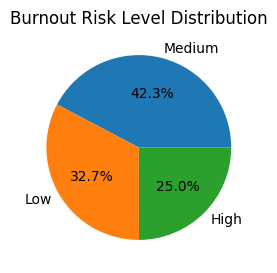

In [12]:
burnout_pct = df['Burnout_Risk_Level'].value_counts() / df.shape[0] * 100

plt.figure(figsize=(3,3))
plt.pie(
    burnout_pct,
    labels=burnout_pct.index,
    autopct='%1.1f%%'
)

plt.title('Burnout Risk Level Distribution')
plt.show()

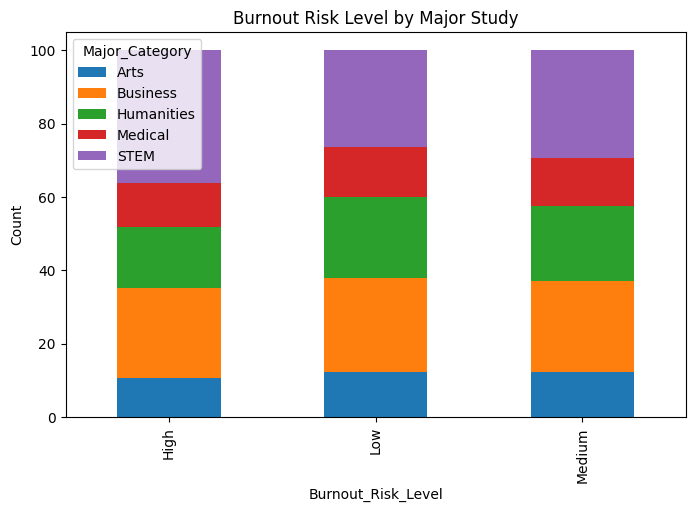

In [13]:
(pd.crosstab(
    df['Burnout_Risk_Level'],df['Major_Category'],normalize='index'
)*100).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Burnout Risk Level by Major Study')
plt.ylabel('Count')
plt.show()

## Analysis of Burnout Risk by Major Category:

The results indicate that students from **STEM disciplines** represent the largest proportion within the **High Burnout Risk** category, accounting for approximately **36.17%** of all students classified as high risk. This percentage is notably higher than that of students from Business (24.43%), Humanities (16.60%), Medical (12.01%), and Arts (10.78%).

This suggests that students pursuing STEM-related fields may be more susceptible to experiencing higher levels of burnout. Possible contributing factors could include demanding coursework, intensive project requirements, challenging technical subjects, and increased academic pressure. However, further analysis would be required to determine the underlying causes and establish whether the relationship is statistically significant.


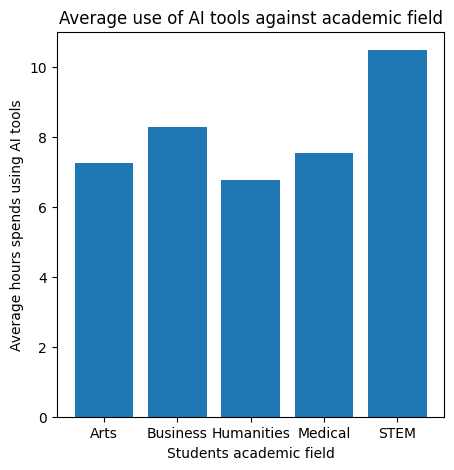

In [14]:
major_cat=df.groupby('Major_Category')['Weekly_GenAI_Hours'].mean()
plt.figure(figsize=(5,5))

plt.bar(major_cat.index,major_cat.values)

plt.xlabel('Students academic field')
plt.ylabel('Average hours spends using AI tools')

plt.title('Average use of AI tools against academic field')

plt.show()

STEM students exhibit both the highest average AI usage and the largest representation within the high burnout risk category. This suggests a potential relationship between academic demands, AI tool usage, and burnout levels, though further analysis would be needed to establish causation.

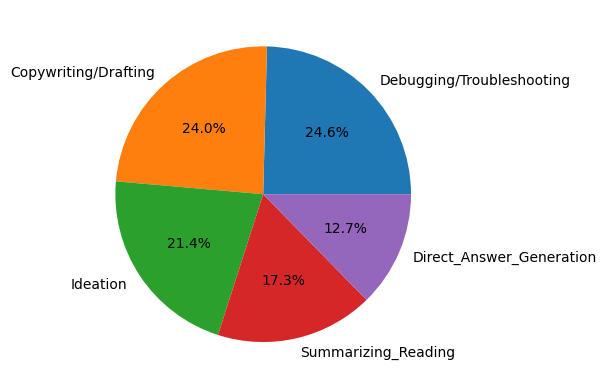

In [15]:
use_case = df['Primary_Use_Case'].value_counts()/df.shape[0]*100

plt.pie(
    use_case,
    labels=use_case.index,
    autopct='%1.1f%%'
)

plt.show()

## Analysis of Primary Use Case:

The analysis shows that students primarily use AI tools for **Debugging/Troubleshooting (24.59%)** and **Copywriting/Drafting (24.02%)**, followed by **Ideation (21.44%)** and **Summarizing/Reading (17.27%)**. Only **12.68%** of usage is for **Direct Answer Generation**.

This is a positive indicator, as it suggests that most students are leveraging AI as a learning and productivity assistant rather than relying on it solely to obtain direct answers. The higher usage for debugging, drafting, and idea generation indicates that students are using AI to enhance their problem-solving skills, improve their work quality, and support their learning process.


In [16]:
pd.crosstab(df['Prompt_Engineering_Skill'],df['Burnout_Risk_Level'],normalize='index')*100

Burnout_Risk_Level,High,Low,Medium
Prompt_Engineering_Skill,,,
Advanced,25.512347,32.044319,42.443334
Beginner,24.639092,33.062990,42.297918
Intermediate,24.903933,32.939647,42.156420


## prompt engineering skill

The distribution of burnout risk levels remains remarkably consistent across Advanced, Beginner, and Intermediate prompt engineering skill levels. Approximately 42% of students fall into the Medium burnout category, around 33% into the Low category, and 25% into the High category regardless of their prompt engineering proficiency. This suggests that prompt engineering skill does not appear to have a significant relationship with burnout risk in this dataset.

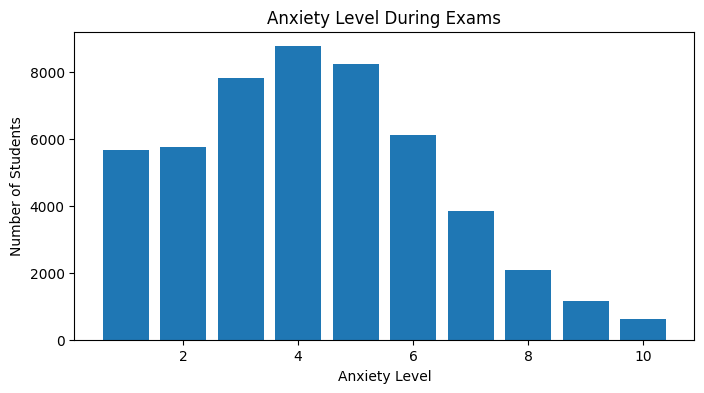

In [17]:
anxiety_counts = df['Anxiety_Level_During_Exams'].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(anxiety_counts.index, anxiety_counts.values)

plt.xlabel('Anxiety Level')
plt.ylabel('Number of Students')
plt.title('Anxiety Level During Exams')
plt.show()

## Analysis of Anxiety Levels During Exams:

The distribution of exam anxiety levels shows that most students report **moderate anxiety levels**, with the highest concentration observed between levels **3 and 5**. Anxiety level **4** is the most common, reported by 8,749 students, followed by level **5** (8,222 students) and level **3** (7,806 students).

As anxiety levels increase beyond 5, the number of students declines steadily. Only 620 students reported the maximum anxiety level of **10**, indicating that extremely high exam anxiety is relatively uncommon within the dataset.

Overall, the data suggests that while exam-related anxiety is widespread among students, the majority experience it at moderate rather than extreme levels. This pattern indicates that exam stress is a common part of the student experience, but severe anxiety affects a smaller proportion of the population.


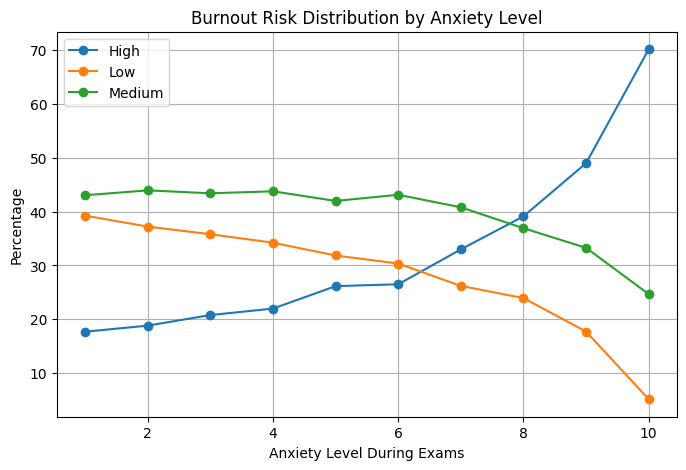

In [18]:
plt.figure(figsize=(8,5))
burnout_anxiety = pd.crosstab(
    df['Anxiety_Level_During_Exams'],
    df['Burnout_Risk_Level'],
    normalize='index'
) * 100

for col in burnout_anxiety.columns:
    plt.plot(
        burnout_anxiety.index,
        burnout_anxiety[col],
        marker='o',
        label=col
    )

plt.xlabel('Anxiety Level During Exams')
plt.ylabel('Percentage')
plt.title('Burnout Risk Distribution by Anxiety Level')
plt.legend()
plt.grid(True)

plt.show()

## Analysis of Anxiety Levels and Burnout Risk:

The analysis reveals a strong positive relationship between exam anxiety and burnout risk. As anxiety levels increase from 1 to 10, the proportion of students classified as having a **High Burnout Risk** rises substantially.

At anxiety level 1, only **17.7%** of students fall into the High Burnout category. This percentage steadily increases with each anxiety level, reaching **39.1%** at level 8, **49.0%** at level 9, and an alarming **70.2%** at the maximum anxiety level of 10.

Conversely, the proportion of students with **Low Burnout Risk** decreases sharply as anxiety increases, dropping from **39.3%** at anxiety level 1 to just **5.2%** at anxiety level 10.

These findings suggest that exam anxiety is one of the strongest indicators of burnout risk among students. Students experiencing higher levels of exam-related anxiety are significantly more likely to exhibit symptoms associated with high burnout risk.


In [19]:
pd.crosstab(df['Institutional_Policy'],df['Burnout_Risk_Level'],normalize='index')*100

Burnout_Risk_Level,High,Low,Medium
Institutional_Policy,,,
Actively_Encouraged,23.772351,33.887110,42.340539
Allowed_With_Citation,23.830479,32.984459,43.185062
Strict_Ban,29.760932,30.343277,39.895791


## Analysis of Institutional AI Policy and Burnout Risk:

A notable difference is observed across institutional AI policies. Students attending institutions with a **Strict Ban** on AI tools show a **High Burnout Risk rate of 29.76%**, compared with approximately **23.8%** among students in institutions where AI use is actively encouraged or allowed with citation.

This represents an increase of nearly **6 percentage points** in the proportion of students experiencing high burnout risk. Additionally, institutions with a strict ban show lower proportions of students in the Medium Burnout category.

These findings suggest that restrictive AI policies may be associated with higher levels of student burnout. One possible explanation is that students in such environments have reduced access to productivity and learning support tools that could help manage academic workload. However, further analysis would be required to determine whether the institutional policy itself contributes to burnout or whether other factors are influencing the relationship.


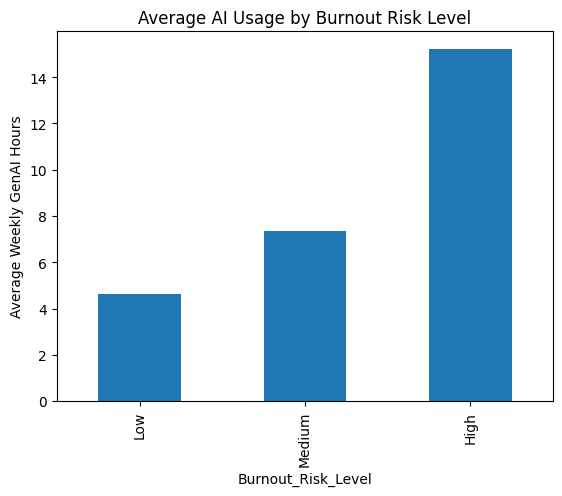

In [20]:
df.groupby('Burnout_Risk_Level')['Weekly_GenAI_Hours']\
  .mean()\
  .sort_values()\
  .plot(kind='bar')

plt.ylabel('Average Weekly GenAI Hours')
plt.title('Average AI Usage by Burnout Risk Level')
plt.show()

## Analysis of AI Usage and Burnout Risk:

A strong relationship is observed between Generative AI usage and burnout risk. Students classified as having **High Burnout Risk** spend an average of **15.21 hours per week** using AI tools, compared with **7.35 hours** for Medium Burnout students and **4.64 hours** for Low Burnout students.

This pattern suggests that students experiencing higher levels of burnout tend to rely more heavily on AI tools. One possible explanation is that students facing greater academic pressure, workload demands, or stress may use AI more frequently to assist with studying, assignments, problem-solving, and productivity tasks.

However, the analysis does not establish causation. Higher AI usage may be a consequence of increased workload and stress rather than the direct cause of burnout.


In [21]:
str_col= df.select_dtypes(include='object').columns

In [22]:
str_col=str_col.drop('Burnout_Risk_Level')

In [23]:
str_col

Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Institutional_Policy'],
      dtype='object')

In [24]:
df = pd.get_dummies(df, columns=str_col, dtype=int)


In [25]:
df=pd.get_dummies(df,columns=['Paid_Subscription'],dtype=int)

In [26]:
from sklearn.preprocessing import OrdinalEncoder
#LabelEncoder assigns labels alphabetically and doesn't preserve the business meaning or natural order of categories. 
#For ordinal data such as Low, Medium, and High, 
#I prefer using a custom mapping or OrdinalEncoder so that the encoded values reflect the true order of the categories

oe = OrdinalEncoder(
    categories=[['Low', 'Medium', 'High']]
)

df[['Burnout_Risk_Level']] = oe.fit_transform(
    df[['Burnout_Risk_Level']]
)

In [27]:
mapping = {
    category: idx
    for idx, category in enumerate(oe.categories_[0])
}

print(mapping)

{'Low': 0, 'Medium': 1, 'High': 2}


In [28]:
df.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,Major_Category_Arts,...,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Paid_Subscription_False,Paid_Subscription_True
0,2.418,23.31,1,8.13,5,6,2.393,86.44,2.0,0,...,0,0,0,1,0,0,1,0,0,1
1,3.821,1.12,5,16.65,3,9,3.696,69.39,0.0,0,...,1,0,1,0,0,0,1,0,1,0
2,3.398,21.26,2,10.35,5,9,3.499,73.93,1.0,0,...,0,1,0,1,0,0,0,1,1,0
3,3.789,1.82,4,15.23,2,2,4.000,63.58,1.0,0,...,0,0,0,0,1,0,1,0,1,0
4,3.635,9.29,4,12.55,4,4,3.798,100.00,1.0,0,...,0,0,1,0,0,0,1,0,1,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Pre_Semester_GPA                            50000 non-null  float64
 1   Weekly_GenAI_Hours                          50000 non-null  float64
 2   Tool_Diversity                              50000 non-null  int64  
 3   Traditional_Study_Hours                     50000 non-null  float64
 4   Perceived_AI_Dependency                     50000 non-null  int64  
 5   Anxiety_Level_During_Exams                  50000 non-null  int64  
 6   Post_Semester_GPA                           50000 non-null  float64
 7   Skill_Retention_Score                       50000 non-null  float64
 8   Burnout_Risk_Level                          50000 non-null  float64
 9   Major_Category_Arts                         50000 non-null  int32  
 10  Major_Cate

In [30]:
df.columns

Index(['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'Major_Category_Arts',
       'Major_Category_Business', 'Major_Category_Humanities',
       'Major_Category_Medical', 'Major_Category_STEM',
       'Year_of_Study_Freshman', 'Year_of_Study_Graduate',
       'Year_of_Study_Junior', 'Year_of_Study_Senior',
       'Year_of_Study_Sophomore', 'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading',
       'Prompt_Engineering_Skill_Advanced',
       'Prompt_Engineering_Skill_Beginner',
       'Prompt_Engineering_Skill_Intermediate',
       'Institutional_Policy_Actively_Encouraged',
       'Institutional_Policy_Allowed_With_Citation',
       '

In [31]:
df.corr()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,Major_Category_Arts,...,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Paid_Subscription_False,Paid_Subscription_True
Pre_Semester_GPA,1.000000,-0.001084,-0.005671,-0.004620,0.000701,-0.000667,0.926781,0.099019,-0.096234,0.000524,...,-0.002561,0.006627,-0.006801,0.004888,0.001424,0.002169,-0.001640,-0.000437,0.001027,-0.001027
Weekly_GenAI_Hours,-0.001084,1.000000,0.008411,-0.157368,0.665479,0.269080,-0.018600,-0.118099,0.469472,-0.051296,...,-0.001878,-0.014214,0.019918,-0.013089,-0.005409,0.004008,-0.000928,-0.003459,-0.196943,0.196943
Tool_Diversity,-0.005671,0.008411,1.000000,0.003565,0.006019,0.003189,0.025265,0.196952,0.005783,-0.011606,...,-0.009869,-0.005864,0.522932,-0.511445,0.027411,-0.000415,-0.003797,0.005263,-0.005803,0.005803
Traditional_Study_Hours,-0.004620,-0.157368,0.003565,1.000000,-0.102625,-0.040935,0.137653,0.147565,-0.135789,0.010186,...,-0.006807,0.004795,-0.003444,-0.000738,0.003966,0.003983,-0.006719,0.003868,0.035329,-0.035329
Perceived_AI_Dependency,0.000701,0.665479,0.006019,-0.102625,1.000000,0.307620,-0.014180,-0.084324,0.369318,-0.028610,...,-0.001899,-0.004440,0.007112,-0.005088,-0.001513,0.005051,-0.000026,-0.005799,-0.131033,0.131033
Anxiety_Level_During_Exams,-0.000667,0.269080,0.003189,-0.040935,0.307620,1.000000,-0.015909,-0.041556,0.164505,-0.016511,...,-0.000814,0.000482,0.002004,-0.002641,0.000793,-0.046384,-0.069902,0.141639,-0.065845,0.065845
Post_Semester_GPA,0.926781,-0.018600,0.025265,0.137653,-0.014180,-0.015909,1.000000,0.169616,-0.095543,-0.004154,...,-0.005905,0.000586,0.049383,-0.023030,-0.022923,0.005374,0.008196,-0.016532,-0.005528,0.005528
Skill_Retention_Score,0.099019,-0.118099,0.196952,0.147565,-0.084324,-0.041556,0.169616,1.000000,-0.058140,-0.003790,...,-0.010932,-0.019712,0.290961,-0.270945,0.001496,0.016390,0.008675,-0.029857,0.024083,-0.024083
Burnout_Risk_Level,-0.096234,0.469472,0.005783,-0.135789,0.369318,0.164505,-0.095543,-0.058140,1.000000,-0.016970,...,-0.006359,-0.011465,0.010070,-0.006691,-0.002661,-0.020353,-0.018559,0.046886,-0.103783,0.103783
Major_Category_Arts,0.000524,-0.051296,-0.011606,0.010186,-0.028610,-0.016511,-0.004154,-0.003790,-0.016970,1.000000,...,-0.064367,-0.029681,-0.021381,0.010554,0.009337,0.005200,-0.007184,0.003048,0.009656,-0.009656


In [55]:
from sklearn.model_selection import train_test_split,cross_val_score ,GridSearchCV


In [36]:
X= df.drop(columns=['Burnout_Risk_Level'],axis=1)

In [37]:
y=df['Burnout_Risk_Level']

In [38]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=101)

In [39]:
X_train.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Major_Category_Arts,Major_Category_Business,...,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Paid_Subscription_False,Paid_Subscription_True
32017,3.140,1.91,3,22.54,3,6,3.787,67.06,0,0,...,0,0,0,0,1,1,0,0,0,1
6283,3.163,3.43,3,16.67,2,5,3.239,67.18,0,1,...,0,1,0,0,1,1,0,0,1,0
36493,2.816,0.19,3,9.02,2,4,2.905,77.31,0,0,...,0,0,0,0,1,1,0,0,1,0
42435,3.215,4.38,3,1.00,1,4,3.411,69.53,0,0,...,0,0,1,0,0,0,1,0,1,0
35681,3.203,0.07,3,4.65,2,5,3.238,84.07,0,1,...,0,0,1,0,0,1,0,0,1,0


In [41]:
X_train.shape

(37500, 31)

In [42]:
X_test.shape

(12500, 31)

In [43]:
X_train.shape[0]/df.shape[0]*100

75.0

In [44]:
X_test.shape[0]/df.shape[0]*100

25.0

In [71]:
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
#from sklearn.preprocessing import StandardScaler
import warnings

In [72]:
sc = StandardScaler()

In [79]:
X_train_sc = sc.fit_transform(X_train)

In [81]:
X_test_sc=sc.transform(X_test)

In [82]:
y_train_sc = y_train.to_numpy()
y_test_sc = y_test.to_numpy()

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [75]:
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False)

In [76]:
classifier = Sequential(
    [Dense(8,activation='ReLU'),
    Dense(16,activation='ReLU'),
    Dense(32,activation='ReLU'),
    Dense(8,activation='ReLU'),
    Dense(3,activation='softmax')]
)

In [ ]:
classifier.compile(optimizer='adam',
                  loss='sparse_caregorical_crossentropy',
                  metrics=['accuracy'])
    

In [77]:
classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [83]:
model_history = classifier.fit(X_train_sc,y_train,validation_split=0.33,batch_size=40,epochs=1000,callbacks=[early_stopping])

Epoch 1/1000
629/629 [==============================] - 4s 4ms/step - loss: 0.9988 - accuracy: 0.4704 - val_loss: 0.9360 - val_accuracy: 0.5149
Epoch 2/1000
629/629 [==============================] - 3s 5ms/step - loss: 0.9269 - accuracy: 0.5265 - val_loss: 0.9224 - val_accuracy: 0.5255
Epoch 3/1000
629/629 [==============================] - 2s 3ms/step - loss: 0.9192 - accuracy: 0.5336 - val_loss: 0.9173 - val_accuracy: 0.5271
Epoch 4/1000
629/629 [==============================] - 2s 4ms/step - loss: 0.9157 - accuracy: 0.5348 - val_loss: 0.9182 - val_accuracy: 0.5278
Epoch 5/1000
629/629 [==============================] - 3s 4ms/step - loss: 0.9137 - accuracy: 0.5363 - val_loss: 0.9165 - val_accuracy: 0.5284
Epoch 6/1000
629/629 [==============================] - 3s 4ms/step - loss: 0.9120 - accuracy: 0.5368 - val_loss: 0.9185 - val_accuracy: 0.5273
Epoch 7/1000
629/629 [==============================] - 3s 4ms/step - loss: 0.9114 - accuracy: 0.5356 - val_loss: 0.9158 - val_accuracy:

In [85]:
from sklearn.metrics import classification_report

y_pred = classifier.predict(X_test_sc)
y_pred = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred))

391/391 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

         0.0       0.56      0.39      0.46      4062
         1.0       0.48      0.68      0.56      5288
         2.0       0.67      0.48      0.56      3150

    accuracy                           0.53     12500
   macro avg       0.57      0.52      0.53     12500
weighted avg       0.56      0.53      0.53     12500



In [86]:
from sklearn.inspection import permutation_importance

In [87]:
rf_model=RandomForestClassifier()

In [89]:
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

In [91]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                              Feature  Importance
1                  Weekly_GenAI_Hours    0.100368
14             Year_of_Study_Graduate    0.009264
4             Perceived_AI_Dependency    0.008760
13             Year_of_Study_Freshman    0.006096
7               Skill_Retention_Score    0.000824
28    Institutional_Policy_Strict_Ban    0.000728
0                    Pre_Semester_GPA    0.000680
23  Prompt_Engineering_Skill_Advanced   -0.000056
16               Year_of_Study_Senior   -0.000096
3             Traditional_Study_Hours   -0.000104


In [96]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [97]:
y_pred = xgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.53      0.50      0.51      4062
         1.0       0.49      0.59      0.54      5288
         2.0       0.67      0.48      0.56      3150

    accuracy                           0.53     12500
   macro avg       0.56      0.52      0.54     12500
weighted avg       0.55      0.53      0.53     12500



In [98]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2033 1919  110]
 [1527 3133  628]
 [ 280 1364 1506]]


## Project Conclusion

This project aimed to predict student burnout risk levels (Low, Medium, and High) using factors such as AI usage, study habits, academic performance, and mental well-being indicators.

Multiple machine learning models, including Random Forest, XGBoost, and Artificial Neural Networks (ANN), were trained and evaluated. The best-performing models achieved an accuracy of approximately 53–54%. While the overall accuracy was moderate, further analysis revealed that the problem itself is highly complex due to the behavioral and psychological nature of burnout.

Feature importance analysis showed that Weekly GenAI Usage Hours and Perceived AI Dependency were among the most influential predictors of burnout risk. The confusion matrix indicated that most misclassifications occurred between adjacent burnout levels (Low–Medium and Medium–High), while direct confusion between Low and High burnout levels was relatively low. This suggests that burnout risk behaves as an ordinal outcome, where neighboring categories share similar characteristics.

Overall, the project successfully identified key factors associated with student burnout and demonstrated how machine learning can be used to support early risk identification. Future improvements could include collecting additional behavioral features, exploring ordinal classification techniques, and incorporating more advanced feature engineering to improve predictive performance.